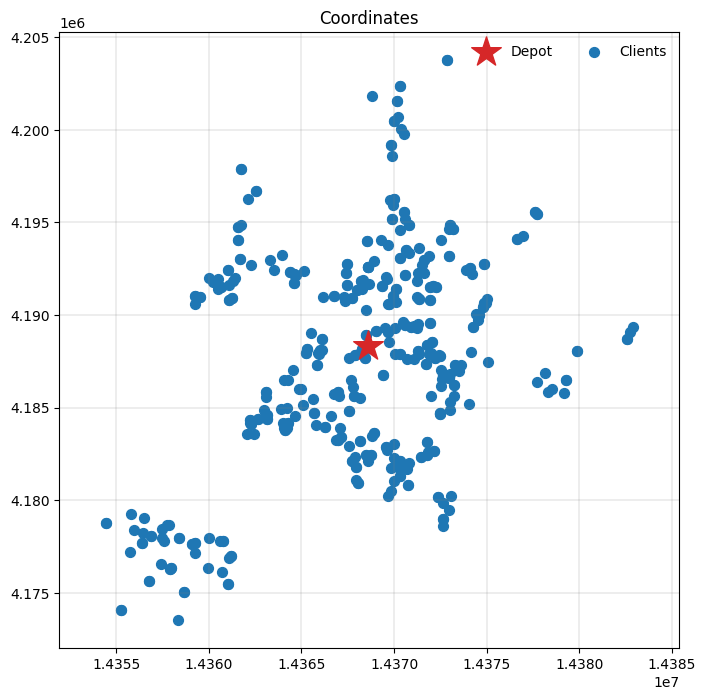

In [27]:
from pyvrp import Model
from pyvrp.stop import MaxRuntime
from pyproj import Transformer
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import math

df = pl.read_csv('/Users/jameslee/cj/cj_challenge/dataset/dataset_df.csv')
matrix = pl.read_csv("/Users/jameslee/cj/cj_challenge/dataset/matrix_df.csv")

truck_capacity = 160 * 280 * 180

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
coords = [transformer.transform(lon, lat) for lon, lat in zip(df['Longitude'], df['Latitude'])]

num_vehicles = math.ceil(df.select('Volume').sum()[0, 0] / truck_capacity)

#average_volume = df.select('Volume').sum()[0, 0]/num_vehicles
#average_volume = (truck_capacity - average_volume) * 0.2 + average_volume

m = Model()
m.add_vehicle_type(num_available=num_vehicles+2, capacity=int(truck_capacity*0.7), fixed_cost=150000, unit_distance_cost=500)
#m.add_vehicle_type(num_available=num_vehicles+3, capacity=70, fixed_cost=150000, unit_distance_cost=500)

index_to_order_number = []
index_to_location_name = []

depot = m.add_depot(x=coords[0][0], y=coords[0][1], name="Depot")
index_to_order_number.append(df['Order_Number'][0])
index_to_location_name.append("Depot")

for idx, row in enumerate(df.iter_rows(named=True)):
    if idx != 0:
        xs = coords[idx][0]
        ys = coords[idx][1]
        deliver = row['Volume']
        m.add_client(
            x=xs,
            y=ys,
            delivery=deliver,
            #delivery=1,
            name=row['Destination']
        )
        index_to_order_number.append(row['Order_Number'])
        index_to_location_name.append(row['Destination'])

for frm in m.locations:
    for to in m.locations:
        origin = frm.name
        destination = to.name
        if origin != destination:
            distance = (matrix.filter((pl.col('ORIGIN') == origin) & (pl.col('DESTINATION') == destination))
                        .select('DISTANCE_METER').to_series().item()) / 1000
            m.add_edge(frm, to, distance=distance)
        else:
            m.add_edge(frm, to, distance=0)

import matplotlib.pyplot as plt
from pyvrp.plotting import plot_coordinates

_, ax = plt.subplots(figsize=(8, 8))
plot_coordinates(m.data(), ax=ax)

In [28]:
res = m.solve(stop=MaxRuntime(300), display=True)

PyVRP v0.11.3

Solving an instance with:
    1 depot
    437 clients
    7 vehicles (1 vehicle type)

                  |       Feasible        |      Infeasible
    Iters    Time |   #      Avg     Best |   #      Avg     Best
H     500     13s |  57  1384263  1156000 |  58  1083344  1011861
H    1000     24s |  39  1346577  1148500 |  43  1097071  1005460
H    1500     36s |  35  1147414  1142000 |  55  1010097   996473
H    2000     46s |  61  1145262  1141500 |  37  1011919   995154
H    2500     56s |  57  1141956  1140000 |  49  1008059   993357
H    3000     66s |  65  1141469  1139000 |  49  1013618   994009
H    3500     76s |  59  1139763  1138000 |  63  1006030   991577
H    4000     85s |  42  1139060  1137500 |  47  1001806   992861
     4500     94s |  44  1138886  1137500 |  53  1004069   991716
     5000    104s |  38  1138789  1137500 |  26   997769   990817
     5500    113s |  38  1138671  1137500 |  34   998041   991262

Search terminated in 120.00s after 5887 itera

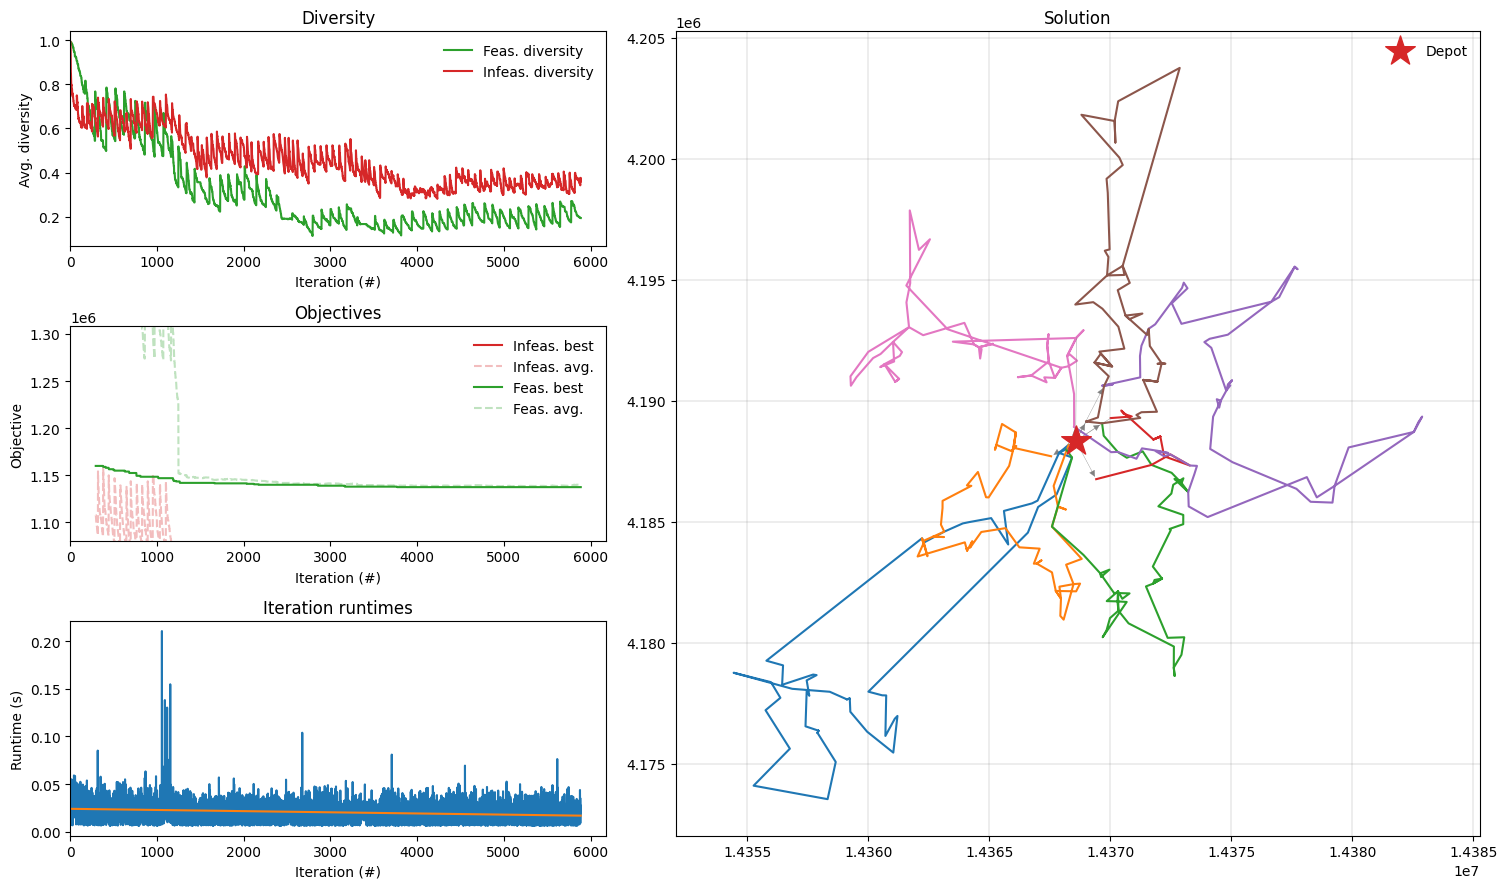

In [29]:
from pyvrp.plotting import plot_result

fig = plt.figure(figsize=(15, 9))
plot_result(res, m.data(), fig)
fig.tight_layout()

In [30]:
routes = [list(route) for route in res.best.routes()]
new_df = df.clear()
for i in range(len(routes)):
    order_map = {order_num: idx for idx, order_num in enumerate(routes[i])}

    filtered_df = (df
        .filter(pl.col('Order_Number').is_in(routes[i]))
        .with_columns(
            pl.col('Order_Number').map_elements(
                lambda x: order_map.get(x, float('inf')), 
                return_dtype=pl.Int64
            ).alias('route_order')
        )
        .sort('route_order')
        .drop('route_order')
    )

    depot_row = pl.DataFrame({
        col: [None] if col != 'Destination' else ['Depot'] 
        for col in filtered_df.columns
    }).cast(dict(zip(filtered_df.columns, filtered_df.dtypes)))

    result = pl.concat([
        depot_row,           
        filtered_df,       
        depot_row          
    ])

    result = result.with_columns(
        (pl.int_range(pl.len())+ 1 ).alias('Route_Order')
    )

    result = result.with_columns(
        pl.lit(i).alias('Vehicle_ID').cast(pl.Int64)
    )
    new_df = pl.concat([new_df, result])
new_df.write_csv('/Users/jameslee/cj/cj_challenge/route_optimization/routes_df.csv')

In [31]:
new_df.group_by('Vehicle_ID').agg(pl.col('Volume').sum()).with_columns(
    pl.lit(truck_capacity).alias('Max_Truck_Capacity')
)

Vehicle_ID,Volume,Max_Truck_Capacity
i64,i64,i32
0,5082000,8064000
1,5622000,8064000
2,5592000,8064000
3,1494000,8064000
4,5604000,8064000
5,5424000,8064000
6,5028000,8064000
